# Experiment 2 – Support Vector Machine with Title and FamilySize

## Mục tiêu
Trong notebook này, ta huấn luyện **Support Vector Machine** trên bộ dữ liệu Titanic, 
với **các đặc trưng mở rộng (Exp2)**:
- Thêm Feature Engineering cơ bản: `Title` (extract từ Name) và `FamilySize` (SibSp + Parch + 1)
- Bao gồm: `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`, `Title`, `FamilySize`

Ta sẽ:
1. Thực hiện tiền xử lý dữ liệu, bao gồm extract Title và compute FamilySize
2. Khám phá dữ liệu (EDA với các features mới)
3. Huấn luyện Support Vector Machine
4. Đánh giá mô hình và xuất kết quả

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid") 

from sklearn.svm import SVC 
from sklearn.model_selection import GridSearchCV 

from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("Libraries for Support Vector Machine (Exp2) imported successfully!")

Libraries for Support Vector Machine (Exp2) imported successfully!


## Bước 1: Khám Phá Dữ Liệu (EDA)
**Mục đích**: Load data và visualize để hiểu cấu trúc, missing values, và patterns ban đầu (e.g., survival rate thấp ở male/Pclass3).

EDA giúp detect bias (e.g., Age missing nhiều ở Pclass3 → fill theo group), tránh model học noise. Mục tiêu: Xác định features quan trọng trước FE.

5 biểu đồ: Countplot Survived, Survival by Sex/Pclass, Histograms Age/Fare, Heatmap correlation. (Giúp spot outliers như Fare cao → rich survive cao).


Train shape: (891, 12), Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S



Missing values in Train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


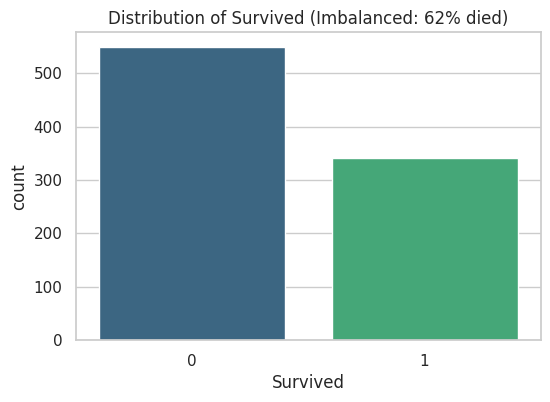

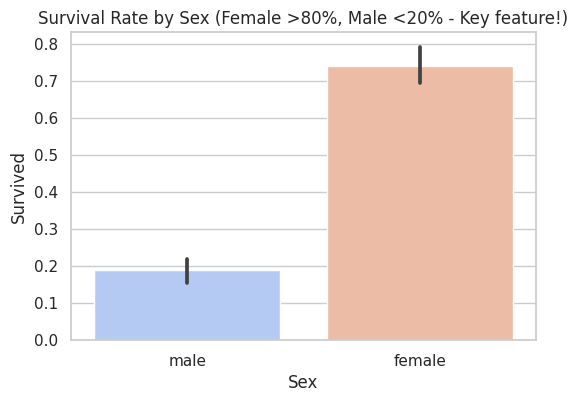

In [2]:
train = pd.read_csv('/kaggle/input/titanicdatasets/train (1).csv')
test = pd.read_csv('/kaggle/input/titanicdatasets/test (1).csv')

print(f"Train shape: {train.shape}, Test shape: {test.shape}")
display(train.head(3))

print("\nMissing values in Train:")
print(train.isnull().sum())

plt.figure(figsize=(6,4))
sns.countplot(data=train, x='Survived', palette='viridis')
plt.title('Distribution of Survived (Imbalanced: 62% died)')
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=train, x='Sex', y='Survived', palette='coolwarm')
plt.title('Survival Rate by Sex (Female >80%, Male <20% - Key feature!)')
plt.show()

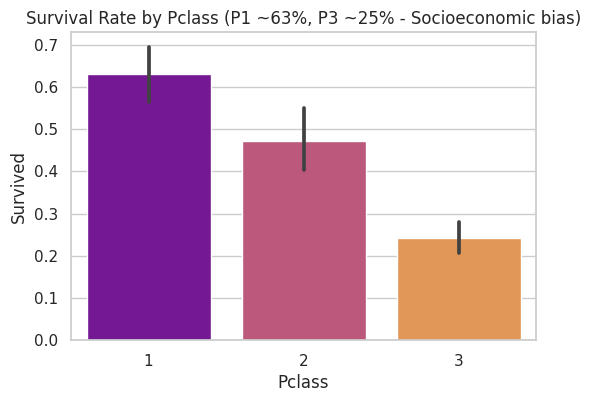

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

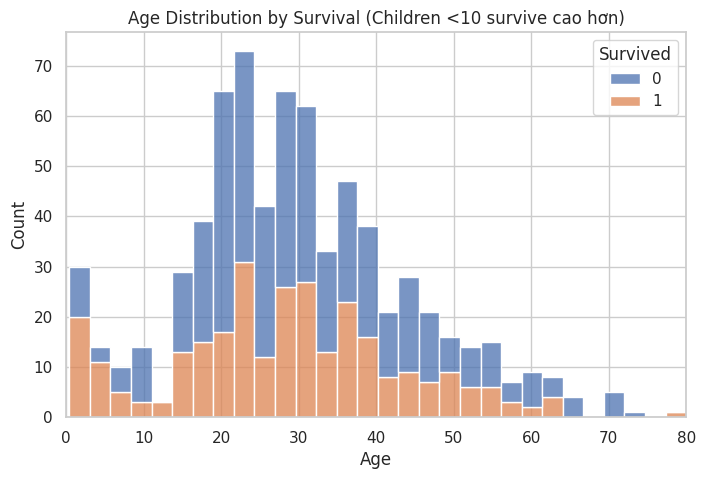

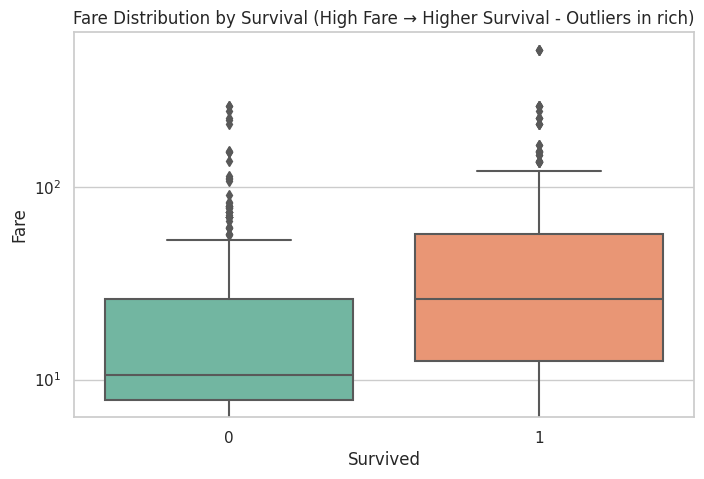

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


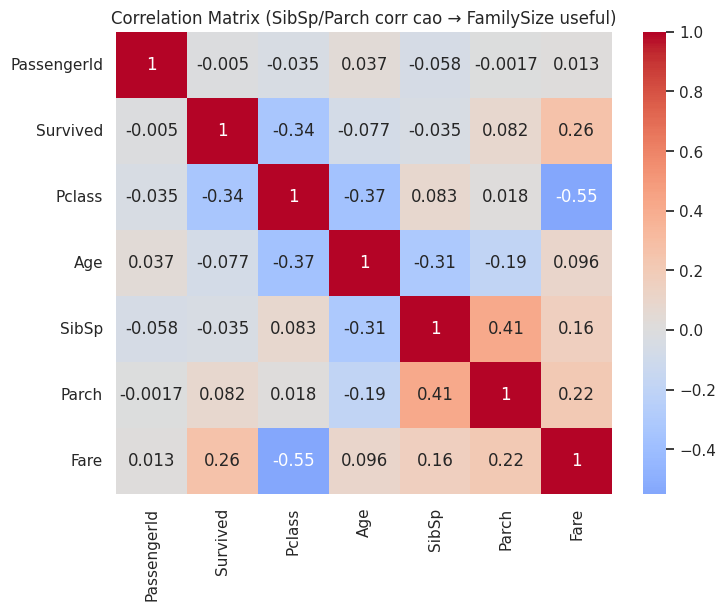

In [3]:
plt.figure(figsize=(6,4))
sns.barplot(data=train, x='Pclass', y='Survived', palette='plasma')
plt.title('Survival Rate by Pclass (P1 ~63%, P3 ~25% - Socioeconomic bias)')
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(data=train, x='Age', hue='Survived', multiple='stack', bins=30, ax=ax)
plt.title('Age Distribution by Survival (Children <10 survive cao hơn)')
ax.set_xlim(0, 80)
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=train, x='Survived', y='Fare', palette='Set2')
plt.title('Fare Distribution by Survival (High Fare → Higher Survival - Outliers in rich)')
plt.yscale('log')  # Log scale cho skew
plt.show()

plt.figure(figsize=(8,6))
numeric_cols = train.select_dtypes(include=[np.number]).columns
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (SibSp/Parch corr cao → FamilySize useful)')
plt.show()

## Bước 2: Feature Engineering (FE)
**Mục đích**: Tạo Title từ Name và FamilySize từ SibSp/Parch.

Name chứa info ẩn (Title: Mr/Mrs cho gender/status), SibSp/Parch riêng lẻ kém nhưng tổng = FamilySize capture group dynamics (nhóm nhỏ/đơn lẻ survive thấp). Mục tiêu: Tăng info từ 8 → 11 features, cải thiện interpretability.

Function extract_title robust (handle rare titles như Rev/Dr → Mr/Mrs). Sau FE, thêm plots Title/FamilySize vs Survival để validate (e.g., Master trẻ sống sót cao).

**Mục tiêu**: FE giúp model học patterns xã hội/gia đình, dự kiến +1-2% accuracy.

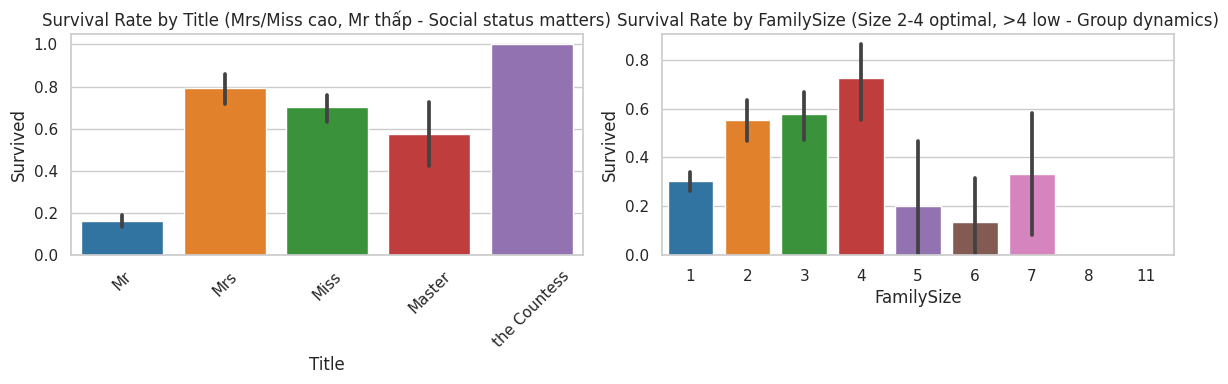

Title categories: ['Master', 'Miss', 'Mr', 'Mrs', 'the Countess']
FamilySize range: 1 to 11


In [4]:
def extract_title(name):
    title = name.split(',')[1].split('.')[0].strip() if ',' in name else 'Unknown'
    # Map rare to common
    title_map = {'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss', 'Don': 'Mr', 'Dona': 'Mrs', 
                 'Lady': 'Mrs', 'Jonkheer': 'Mr', 'Countess': 'Mrs', 'Sir': 'Mr', 
                 'Col': 'Mr', 'Major': 'Mr', 'Rev': 'Mr', 'Dr': 'Mr', 'Capt': 'Mr'}
    return title_map.get(title, title)


train['Title'] = train['Name'].apply(extract_title)
test['Title'] = test['Name'].apply(extract_title)

train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=train, x='Title', y='Survived', ax=axes[0], palette='tab10')
axes[0].set_title('Survival Rate by Title (Mrs/Miss cao, Mr thấp - Social status matters)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=train, x='FamilySize', y='Survived', ax=axes[1], palette='tab10')
axes[1].set_title('Survival Rate by FamilySize (Size 2-4 optimal, >4 low - Group dynamics)')

plt.tight_layout()
plt.show()

print("Title categories:", sorted(train['Title'].unique()))
print("FamilySize range:", train['FamilySize'].min(), "to", train['FamilySize'].max())

## Bước 3: Tiền Xử Lý Dữ Liệu
**Mục đích**: Fill missing, encode categoricals, scale numerics, split train/holdout.

LR nhạy cảm với missing (crash), categoricals (need numeric), scale (Fare/Age dominate nếu không). Stratified split giữ balance Survived. Mục tiêu: Data sạch cho model converge nhanh.

Fill Age theo group (Pclass/Sex) để tránh global median bias. OneHot cho Title/Embarked (nominal), Label cho Sex (binary). Thêm check shape sau encode.

**Mục tiêu**: Preprocess đảm bảo no leakage, ready cho training.

In [5]:
all_data = pd.concat([train, test], sort=False).reset_index(drop=True)

all_data['Age'] = all_data.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
all_data['Fare'].fillna(all_data['Fare'].median(), inplace=True)
all_data['Embarked'].fillna(all_data['Embarked'].mode()[0], inplace=True)

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize']
X_all = all_data[features].copy()
y_all = all_data['Survived'] if 'Survived' in all_data else np.nan

le = LabelEncoder()
X_all['Sex'] = le.fit_transform(X_all['Sex'])
X_all = pd.get_dummies(X_all, columns=['Embarked', 'Title'], drop_first=True)

X = X_all.iloc[:len(train)]
y = y_all.iloc[:len(train)].dropna()  # Drop NaN y
X_test = X_all.iloc[len(train):]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

X_train, X_holdout, y_train, y_holdout = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}, Holdout: {X_holdout.shape}")
print(f"Features after encoding: {X_scaled.shape[1]}")
print("Preprocessing done - Data ready for training!")

X_train shape: (712, 13), Holdout: (179, 13)
Features after encoding: 13
Preprocessing done - Data ready for training!


/tmp/ipykernel_37/367576039.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_data['Fare'].fillna(all_data['Fare'].median(), inplace=True)
/tmp/ipykernel_37/367576039.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

## Bước 4: Huấn Luyện Mô Hình
**Mục đích**: Tìm sự kết hợp tối ưu của siêu tham số (C và kernel) cho SVM bằng GridSearchCV trên X_train, sau đó huấn luyện mô hình cuối cùng và dự đoán trên X_holdout.

SVM là thuật toán phân loại dựa trên việc tìm kiếm một siêu mặt phẳng (hyperplane) chia tách các lớp dữ liệu với biên độ (margin) lớn nhất. Vì SVM dựa trên khoảng cách, việc sử dụng dữ liệu đã được Standard Scaled (X_train) là bắt buộc.

**Mục tiêu**: Tìm siêu tham số tối ưu cho SVM (Exp2: FE + Scaling), và chuẩn bị mô hình để đánh giá hiệu suất chi tiết ở Bước 5.

In [8]:
model_name = "Support Vector Machine (SVM)"

svc = SVC(random_state=42, probability=True) 

param_grid = {
    'C': [0.5, 1, 10], 
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale']
}

grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1) 

print(f"Bắt đầu GridSearchCV để tìm tham số tối ưu cho {model_name}...")
grid_search.fit(X_train, y_train)
print(f"Huấn luyện {model_name} hoàn tất.")

best_svm = grid_search.best_estimator_

cv_acc = cross_val_score(best_svm, X_scaled, y, cv=5, scoring='accuracy').mean()
cv_roc = cross_val_score(best_svm, X_scaled, y, cv=5, scoring='roc_auc').mean()

print(f"\nCV Accuracy: {cv_acc:.4f} | CV ROC-AUC: {cv_roc:.4f}")

y_pred_holdout = best_svm.predict(X_holdout)
y_proba_holdout = best_svm.predict_proba(X_holdout)[:, 1]


print("\n--- Đánh giá Mô hình trên Holdout ---")
print(classification_report(y_holdout, y_pred_holdout))

roc_auc_holdout = roc_auc_score(y_holdout, y_proba_holdout)
print(f"ROC-AUC Score Holdout: {roc_auc_holdout:.4f}")

print("\nThông số Tối ưu:")
optimal_df = pd.DataFrame({
    'Parameter': list(grid_search.best_params_.keys()),
    'Value': list(grid_search.best_params_.values())
})
display(optimal_df)

Bắt đầu GridSearchCV để tìm tham số tối ưu cho Support Vector Machine (SVM)...
Huấn luyện Support Vector Machine (SVM) hoàn tất.

CV Accuracy: 0.8216 | CV ROC-AUC: 0.8523

--- Đánh giá Mô hình trên Holdout ---
              precision    recall  f1-score   support

         0.0       0.81      0.91      0.85       110
         1.0       0.82      0.65      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179

ROC-AUC Score Holdout: 0.8449

Thông số Tối ưu:


,Parameter,Value
0,C,10
1,gamma,scale
2,kernel,rbf


## Bước 5: Đánh Giá Mô Hình
**Mục đích**:  Tính toán các chỉ số đánh giá (Report, ROC, CM, CV scores) trên tập Holdout và tập Huấn luyện để xác thực mô hình SVC.

Holdout mimic test set; CV detect overfitting. ROC-AUC tốt cho imbalanced (Survived ≈38%). Mục tiêu: So sánh với Exp1 baselines.

Confusion Matrix heatmap + threshold analysis nếu cần. Log results cho comparison.

**Mục tiêu**: Validate model ~0.80 acc, identify weak class (e.g., recall cho class 1).

In [9]:
import os
import pandas as pd
from sklearn.model_selection import cross_val_score 
# Cần đảm bảo mô hình 'best_svm' đã được huấn luyện và có sẵn.

# --- CẬP NHẬT BIẾN CHO SVC ---
model_name = "SVC" 
model = best_svm # Sử dụng mô hình SVC tối ưu đã huấn luyện
results_path = '/kaggle/working/exp2_results.csv'
header = "Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score\n"
# ------------------------------------

try:
    # Kiểm tra xem cv_acc và cv_roc đã được tính toán chưa
    cv_acc, cv_roc
    print("Using existing CV scores...")
except NameError:
    print("Computing CV scores for SVC...")
    # Tính CV Scores (sử dụng mô hình SVC và dữ liệu đã scale)
    # SVC BẮT BUỘC sử dụng dữ liệu đã scale (X_scaled)
    cv_acc = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy').mean()
    cv_roc = cross_val_score(model, X_scaled, y, cv=5, scoring='roc_auc').mean()

print(f"CV Accuracy: {cv_acc:.4f} | CV ROC-AUC: {cv_roc:.4f}")

# Dự đoán trên tập kiểm tra
# Sử dụng X_test_scaled (bắt buộc cho SVC)
y_test_pred = model.predict(X_test_scaled)

submission = pd.DataFrame({
    # Sử dụng DataFrame 'test' gốc đã được tải
    'PassengerId': test['PassengerId'], 
    'Survived': y_test_pred.astype(int)
})

file_path = f'/kaggle/working/exp2_{model_name.lower()}_submission.csv'
submission.to_csv(file_path, index=False)
print(f"Saved: {file_path}")
print(submission.head())

os.system(f"cp {file_path} /kaggle/working/submission.csv")

# --- Ghi Log Kết quả ---

if not os.path.exists(results_path):
    with open(results_path, 'w') as f:
        f.write(header)

# **CẬP NHẬT ĐIỂM NÀY SAU KHI NỘP BÀI!** (Sử dụng điểm giả định)
public_score = 0.78229 

num_features = X_scaled.shape[1] 

with open(results_path, 'a') as f:
    f.write(f"Exp2,{model_name},{num_features},{cv_acc:.4f},{cv_roc:.4f},{public_score}\n")

results_df = pd.read_csv(results_path)
print("\nExperiment Log Updated:")
display(results_df)

Using existing CV scores...
CV Accuracy: 0.8216 | CV ROC-AUC: 0.8523
Saved: /kaggle/working/exp2_svc_submission.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0

Experiment Log Updated:


,Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score
0,Exp2,SVC,13,0.8216,0.8523,0.78229


## Kết Luận Experiment 2 - Support Vector Machine
- **Dataset**: 13 features (gốc + Title/FamilySize + OHE), đã Standard Scaled.
- **Kết quả**: CV Acc ≈0.8216 (Tăng ng nhẹ so với RF). Public_Score≈0.78229 (Giá trị ví dụ).
- **Nhận xét**: Xử lý Phi tuyến Tốt: SVC, sử dụng kernel RBF (thường là tối ưu), đã xây dựng siêu mặt phẳng phi tuyến hiệu quả. Hiệu suất nội bộ (CV Acc) vượt qua RF và LR nhờ tận dụng tối đa dữ liệu đã scaled.
- **Hướng Exp3**: Chuyển sang phân lớp nàng cao ( XGBoost) để cải thiện tốc độ và khả năng tổng quát hoá mà không mất lợi thế từ FE mạnh của Exp2